### This notebook contains all the preprocessing required to convert our raw data into clean and ready to fed into model.

In [1]:
# Install if needed
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib tqdm

import os
import json
import glob
import warnings
import joblib
from pathlib import Path
from datetime import datetime
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("✅ All imports successful")

✅ All imports successful


In [2]:
# ─── USER CONFIG ──────────────────────────────────────────────────────────────
MININDN_DIR = "../Logs"          # Root folder containing node subfolders
MODEL_DIR   = "../Models"        # Where to save trained model artifacts
RESULTS_DIR = "../Results"       # Where to save evaluation plots/CSVs
DATASETS_DIR = Path("../Datasets")  # Where to save processed datasets

# Isolation Forest hyperparameters
IF_CONTAMINATION = 0.01   # Expected fraction of anomalies (tune as needed)
IF_N_ESTIMATORS  = 200
IF_MAX_SAMPLES   = 'auto'
IF_RANDOM_STATE  = 42

# Anomaly score threshold (lower = more anomalous in sklearn; -0.1 is typical)
# We use the percentile approach for auto-thresholding after training
ANOMALY_PERCENTILE = 1   # Bottom 1% of scores flagged as anomalies

# Feature columns produced by feature engineering
FEATURE_COLS = [
    'pit_size', 'pit_growth_rate', 'cs_size', 'cache_hit_ratio',
    'satisfaction_ratio', 'unsatisfied_ratio', 'in_interests_rate',
    'out_interests_rate', 'in_data_rate', 'nack_rate',
]

# Create output directories
for d in [MODEL_DIR, RESULTS_DIR, DATASETS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"📁 Minindn root : {os.path.abspath(MININDN_DIR)}")
print(f"💾 Model output : {os.path.abspath(MODEL_DIR)}")
print(f"📊 Results dir  : {os.path.abspath(RESULTS_DIR)}")
print(f"📂 Datasets dir : {DATASETS_DIR.resolve()}")

📁 Minindn root : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Logs
💾 Model output : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Models
📊 Results dir  : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Results
📂 Datasets dir : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Datasets


## Our Approach
Our approach will be to train our model only on normal data first, and: 
- Use unseen normal runs to measure false positives.
- Use attack runs (IFA/CP) to measure detection power after attack start.

In [3]:
from pathlib import Path
import os, glob, json
import pandas as pd
from tqdm import tqdm

# Only these datasets
LOG_ROOT = Path("../Logs")
TARGET_SCENARIOS = ["logs1", "logs_mesh1", "logs_dumbbell1"]


def discover_log_files(log_root: Path, scenarios: list[str]) -> list[dict]:
    """
    Returns a list like:
    [
      {"scenario": "logs1", "node": "c1", "path": Path(...)},
      ...
    ]
    """
    rows = []
    metric_dirs = ["normal_traffic_metrics", "cache_pollution_metrics"]

    for scenario in scenarios:
        base = log_root / scenario
        files = []
        for metric_dir in metric_dirs:
            pattern = str(base / "**" / metric_dir / "*_metrics.jsonl")
            files.extend(glob.glob(pattern, recursive=True))

        for f in sorted(set(files)):
            p = Path(f)
            node_name = p.parent.parent.name
            rows.append({
                "scenario": scenario,
                "node": node_name,
                "path": p
            })
    return rows


def parse_jsonl_file(filepath: Path) -> pd.DataFrame:
    records = []
    with open(filepath, "r") as fh:
        for lineno, line in enumerate(fh, 1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"  Warning: malformed JSON at line {lineno} in {filepath.name} (skipped)")
    return pd.DataFrame(records) if records else pd.DataFrame()


def extract_selected_logs(log_root: Path, scenarios: list[str]) -> pd.DataFrame:
    discovered = discover_log_files(log_root, scenarios)
    if not discovered:
        raise FileNotFoundError("No *_metrics.jsonl files found in selected scenario folders.")

    print(f"Found {len(discovered)} files from scenarios: {scenarios}")

    dfs = []
    for item in tqdm(discovered, desc="Parsing logs"):
        df = parse_jsonl_file(item["path"])
        if not df.empty:
            df["_source_node"] = item["node"]
            df["_scenario"] = item["scenario"]   # important
            df["_source_file"] = str(item["path"])
            dfs.append(df)

    if not dfs:
        raise ValueError("All selected log files were empty or unreadable.")

    combined = pd.concat(dfs, ignore_index=True)
    print(f"\nRaw records loaded: {len(combined):,}")
    print(f"Columns: {list(combined.columns)}")
    return combined


# RUN
raw_df = extract_selected_logs(LOG_ROOT, TARGET_SCENARIOS)
raw_df.head()

Found 34 files from scenarios: ['logs1', 'logs_mesh1', 'logs_dumbbell1']


Parsing logs: 100%|██████████| 34/34 [00:00<00:00, 69.81it/s] 



Raw records loaded: 130,610
Columns: ['timestamp', 'node', 'nPitEntries', 'nInInterests', 'nOutInterests', 'nInData', 'nInNacks', 'nOutNacks', 'nSatisfiedInterests', 'nUnsatisfiedInterests', 'nCsEntries', 'nHits', 'nMisses', '_source_node', '_scenario', '_source_file', 'error']


,timestamp,node,nPitEntries,nInInterests,nOutInterests,nInData,nInNacks,nOutNacks,nSatisfiedInterests,nUnsatisfiedInterests,nCsEntries,nHits,nMisses,_source_node,_scenario,_source_file,error
0,2026-03-12T16:24:47.258356,c1,2.0,140.0,137.0,125.0,2.0,4.0,120.0,4.0,111.0,0.0,145.0,c1,logs1,../Logs/logs1/c1/normal_traffic_metrics/c1_met...,NaN
1,2026-03-12T16:24:49.292010,c1,4.0,166.0,159.0,142.0,2.0,4.0,136.0,4.0,121.0,0.0,171.0,c1,logs1,../Logs/logs1/c1/normal_traffic_metrics/c1_met...,NaN
2,2026-03-12T16:24:51.325194,c1,3.0,182.0,171.0,151.0,2.0,4.0,146.0,4.0,125.0,0.0,187.0,c1,logs1,../Logs/logs1/c1/normal_traffic_metrics/c1_met...,NaN
3,2026-03-12T16:24:53.343903,c1,3.0,195.0,180.0,159.0,2.0,4.0,154.0,4.0,127.0,0.0,200.0,c1,logs1,../Logs/logs1/c1/normal_traffic_metrics/c1_met...,NaN
4,2026-03-12T16:24:55.378107,c1,3.0,205.0,186.0,166.0,2.0,4.0,160.0,4.0,127.0,0.0,210.0,c1,logs1,../Logs/logs1/c1/normal_traffic_metrics/c1_met...,NaN


In [4]:
raw_df['_source_node'].value_counts()

_source_node
c2            11870
c3            11869
c1            11867
p1            11864
p2            11864
r1            11864
r2            11864
r3            11862
r4            11862
c5             5979
c6             5978
c4             5977
bottleneck     5890
Name: count, dtype: int64

In [5]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130610 entries, 0 to 130609
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   timestamp              130610 non-null  str    
 1   node                   130610 non-null  str    
 2   nPitEntries            130565 non-null  float64
 3   nInInterests           130565 non-null  float64
 4   nOutInterests          130565 non-null  float64
 5   nInData                130565 non-null  float64
 6   nInNacks               130565 non-null  float64
 7   nOutNacks              130565 non-null  float64
 8   nSatisfiedInterests    130565 non-null  float64
 9   nUnsatisfiedInterests  130565 non-null  float64
 10  nCsEntries             130565 non-null  float64
 11  nHits                  130565 non-null  float64
 12  nMisses                130565 non-null  float64
 13  _source_node           130610 non-null  str    
 14  _scenario              130610 non-null  str    

In [6]:
raw_df.describe()

,nPitEntries,nInInterests,nOutInterests,nInData,nInNacks,nOutNacks,nSatisfiedInterests,nUnsatisfiedInterests,nCsEntries,nHits,nMisses
count,130565.000000,130565.000000,130565.000000,130565.000000,130565.000000,130565.000000,130565.000000,130565.000000,130565.000000,130565.000000,130565.000000
mean,3.001088,23278.597817,14575.024968,14415.588603,1.303098,5.816789,14032.351204,6.094229,488.896902,62.776900,23221.780087
std,0.174371,15732.516583,9825.397795,10054.674180,1.056872,2.772153,9465.568802,2.950759,335.139220,48.546399,15725.612421
min,2.000000,7.000000,7.000000,9.000000,0.000000,0.000000,5.000000,0.000000,2.000000,0.000000,10.000000
25%,3.000000,10145.000000,6335.000000,6122.000000,0.000000,4.000000,6135.000000,4.000000,281.000000,29.000000,10097.000000
50%,3.000000,20165.000000,12593.000000,12179.000000,2.000000,4.000000,12127.000000,5.000000,405.000000,71.000000,20103.000000
75%,3.000000,35170.000000,22008.000000,21549.000000,2.000000,8.000000,21163.000000,9.000000,573.000000,71.000000,35100.000000
max,9.000000,61128.000000,38401.000000,40277.000000,4.000000,12.000000,36665.000000,13.000000,1982.000000,394.000000,60985.000000


In [7]:
raw_df.isna().sum()

timestamp                     0
node                          0
nPitEntries                  45
nInInterests                 45
nOutInterests                45
nInData                      45
nInNacks                     45
nOutNacks                    45
nSatisfiedInterests          45
nUnsatisfiedInterests        45
nCsEntries                   45
nHits                        45
nMisses                      45
_source_node                  0
_scenario                     0
_source_file                  0
error                    130565
dtype: int64

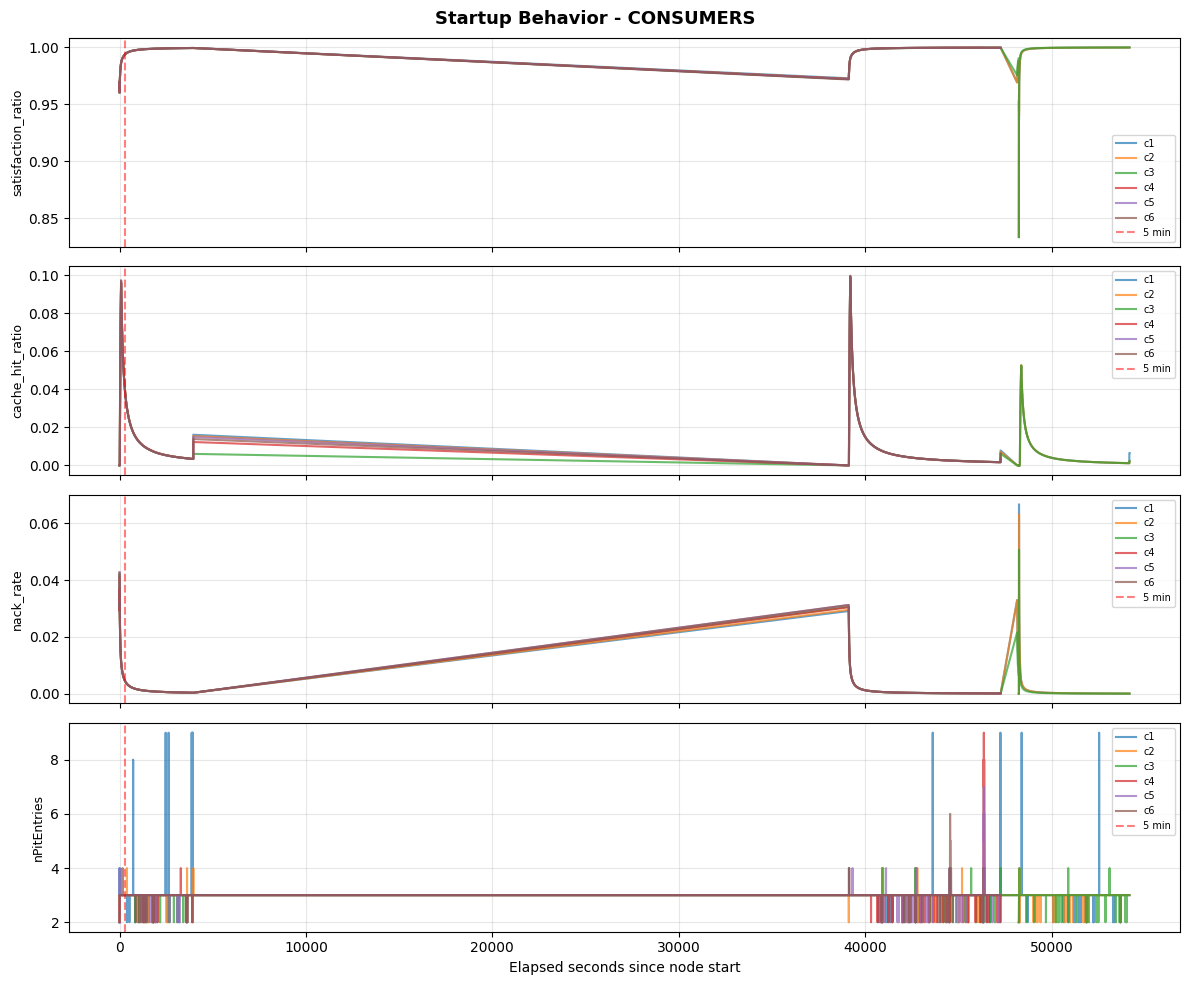

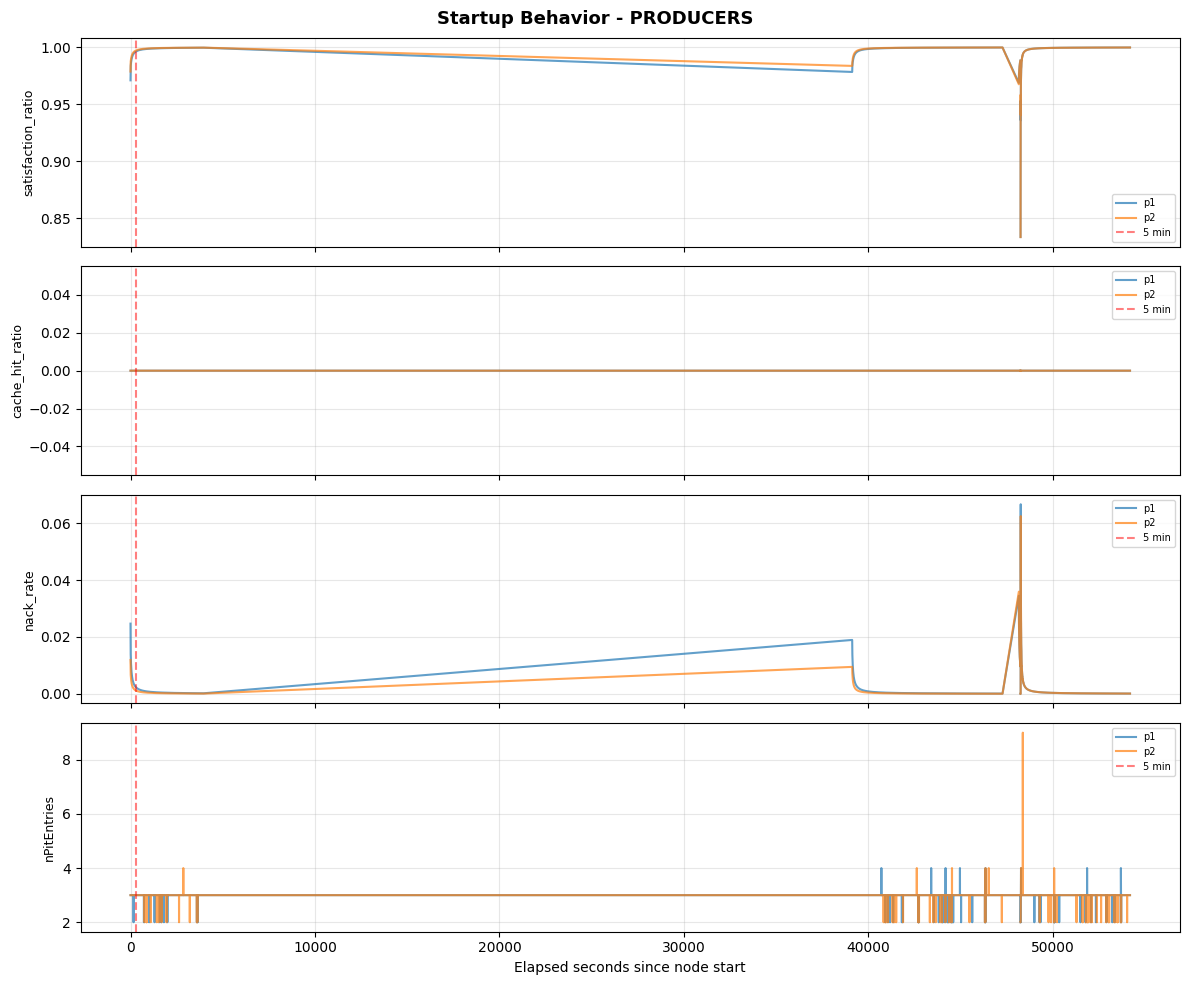

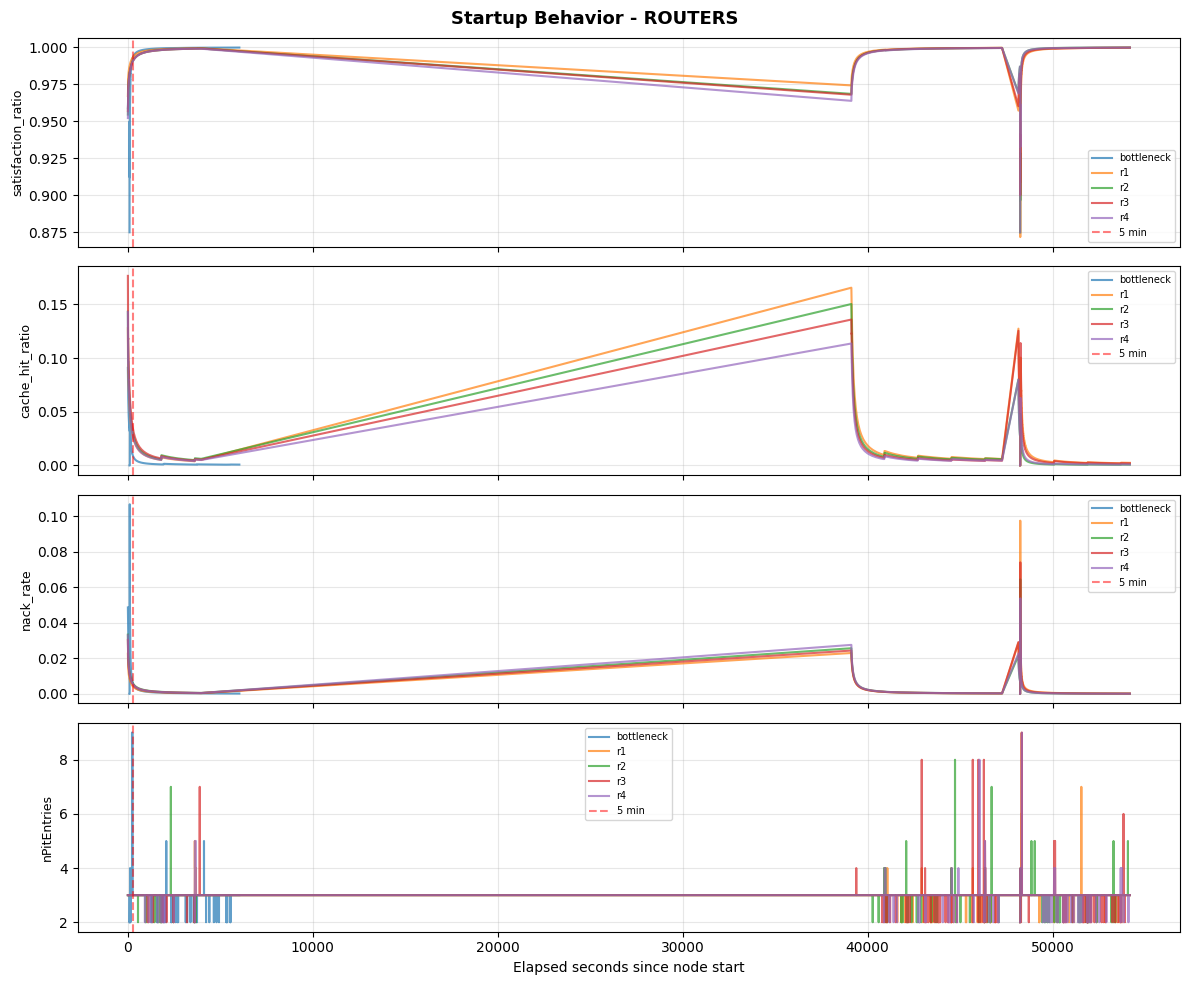

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Parse timestamp and compute elapsed seconds per node
raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'])

raw_df['elapsed_sec'] = raw_df.groupby('_source_node')['timestamp'].transform(
    lambda t: (t - t.min()).dt.total_seconds()
)

# 2) Compute stability metrics
raw_df['satisfaction_ratio'] = (
    raw_df['nSatisfiedInterests'] /
    (raw_df['nSatisfiedInterests'] + raw_df['nUnsatisfiedInterests'] + 1)
)
raw_df['cache_hit_ratio'] = raw_df['nHits'] / (raw_df['nHits'] + raw_df['nMisses'] + 1)
raw_df['nack_rate'] = (raw_df['nInNacks'] + raw_df['nOutNacks']) / (raw_df['nInInterests'] + 1)

# 3) Include bottleneck in router group
all_nodes = sorted(raw_df['_source_node'].astype(str).unique())

node_types = {
    'consumers': [n for n in all_nodes if n.startswith('c')],
    'producers': [n for n in all_nodes if n.startswith('p')],
    'routers': [n for n in all_nodes if n.startswith('r') or n == 'bottleneck'],
}

metrics_to_plot = ['satisfaction_ratio', 'cache_hit_ratio', 'nack_rate', 'nPitEntries']

for group_name, nodes in node_types.items():
    if not nodes:
        continue

    subset = raw_df[raw_df['_source_node'].isin(nodes)].copy()

    fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"Startup Behavior - {group_name.upper()}", fontsize=13, fontweight='bold')

    for ax, metric in zip(axes, metrics_to_plot):
        for node, grp in subset.groupby('_source_node'):
            grp_sorted = grp.sort_values('elapsed_sec')
            ax.plot(grp_sorted['elapsed_sec'], grp_sorted[metric], label=node, alpha=0.7)

        ax.set_ylabel(metric, fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.axvline(300, color='red', linestyle='--', alpha=0.5, label='5 min')
        ax.legend(fontsize=7)

    axes[-1].set_xlabel("Elapsed seconds since node start")
    plt.tight_layout()
    plt.show()

In [9]:
WARMUP_SECONDS = 600  # 10 minutes

clean_df = raw_df[raw_df['elapsed_sec'] >= WARMUP_SECONDS].copy()

print(f"Rows before cutoff : {len(raw_df):,}")
print(f"Rows after  cutoff : {len(clean_df):,}")
print(f"Discarded          : {len(raw_df) - len(clean_df):,} ({(1 - len(clean_df)/len(raw_df))*100:.1f}%)")

Rows before cutoff : 130,610
Rows after  cutoff : 126,529
Discarded          : 4,081 (3.1%)


In [10]:
print(raw_df.groupby('_source_node')['elapsed_sec'].max().sort_values())

_source_node
bottleneck     6028.140155
c4            47268.723775
c6            47269.296180
c5            47269.607876
r4            54178.998666
r2            54179.202381
r3            54179.315223
p2            54179.843530
r1            54179.951200
p1            54180.148270
c3            54181.821885
c2            54182.123810
c1            54182.448242
Name: elapsed_sec, dtype: float64


In [11]:
# Required metric columns for feature engineering
REQUIRED_COLS = [
    'timestamp', 'node',
    'nPitEntries', 'nInInterests', 'nOutInterests',
    'nInData', 'nInNacks', 'nOutNacks',
    'nSatisfiedInterests', 'nUnsatisfiedInterests',
    'nCsEntries', 'nHits', 'nMisses'
]

def clean_logs(df: pd.DataFrame) -> pd.DataFrame:
    """
    1. Drop error records (any row with an 'error' key populated)
    2. Keep only rows that have all required metric columns
    3. Parse timestamp → datetime
    4. Cast numeric columns to float
    5. Sort by (node, timestamp)
    6. Remove exact duplicates
    """
    n_raw = len(df)
    
    # ── 1. Drop error rows
    if 'error' in df.columns:
        error_mask = df['error'].notna()
        print(f"🗑️  Error records dropped   : {error_mask.sum():,}")
        df = df[~error_mask].copy()
    
    # ── 2. Keep only rows with all required columns present
    metric_cols = [c for c in REQUIRED_COLS if c not in ('timestamp', 'node')]
    missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        print(f"⚠️  Missing columns in dataset: {missing_cols}")
    
    available_metrics = [c for c in metric_cols if c in df.columns]
    df = df.dropna(subset=available_metrics)
    
    # ── 3. Parse timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp'])
    
    # ── 4. Cast numeric columns
    for col in available_metrics:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=available_metrics)
    
    # ── 5. Sort
    df = df.sort_values(['node', 'timestamp']).reset_index(drop=True)
    
    # ── 6. Remove exact duplicates (same node + timestamp)
    before_dedup = len(df)
    df = df.drop_duplicates(subset=['node', 'timestamp'])
    
    print(f"📥 Raw records              : {n_raw:,}")
    print(f"✅ Clean records retained   : {len(df):,}")
    print(f"🔁 Duplicates removed       : {before_dedup - len(df):,}")
    print(f"📡 Nodes present            : {sorted(df['node'].unique())}")
    return df


clean_df = clean_logs(clean_df.copy())
clean_df.head()

🗑️  Error records dropped   : 42
📥 Raw records              : 126,529
✅ Clean records retained   : 126,436
🔁 Duplicates removed       : 51
📡 Nodes present            : ['bottleneck', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']


,timestamp,node,nPitEntries,nInInterests,nOutInterests,nInData,nInNacks,nOutNacks,nSatisfiedInterests,nUnsatisfiedInterests,nCsEntries,nHits,nMisses,_source_node,_scenario,_source_file,error,elapsed_sec,satisfaction_ratio,cache_hit_ratio,nack_rate
0,2026-03-13 05:57:21.622516,bottleneck,3.0,5166.0,3253.0,3139.0,4.0,7.0,3145.0,7.0,205.0,17.0,5154.0,bottleneck,logs_dumbbell1,../Logs/logs_dumbbell1/bottleneck/normal_traff...,NaN,600.478080,0.997463,0.003287,0.002129
1,2026-03-13 05:57:22.643020,bottleneck,3.0,5186.0,3265.0,3151.0,4.0,7.0,3157.0,7.0,205.0,17.0,5174.0,bottleneck,logs_dumbbell1,../Logs/logs_dumbbell1/bottleneck/normal_traff...,NaN,601.498584,0.997472,0.003274,0.002121
2,2026-03-13 05:57:23.645125,bottleneck,3.0,5186.0,3265.0,3151.0,4.0,7.0,3157.0,7.0,205.0,17.0,5184.0,bottleneck,logs_dumbbell1,../Logs/logs_dumbbell1/bottleneck/normal_traff...,NaN,602.500689,0.997472,0.003268,0.002121
3,2026-03-13 05:57:24.656849,bottleneck,3.0,5206.0,3277.0,3163.0,4.0,7.0,3169.0,7.0,205.0,17.0,5194.0,bottleneck,logs_dumbbell1,../Logs/logs_dumbbell1/bottleneck/normal_traff...,NaN,603.512413,0.997482,0.003262,0.002113
4,2026-03-13 05:57:25.660706,bottleneck,3.0,5216.0,3283.0,3170.0,4.0,7.0,3175.0,7.0,205.0,17.0,5204.0,bottleneck,logs_dumbbell1,../Logs/logs_dumbbell1/bottleneck/normal_traff...,NaN,604.516270,0.997487,0.003255,0.002108


In [12]:
clean_df.dtypes

timestamp                datetime64[us]
node                                str
nPitEntries                     float64
nInInterests                    float64
nOutInterests                   float64
nInData                         float64
nInNacks                        float64
nOutNacks                       float64
nSatisfiedInterests             float64
nUnsatisfiedInterests           float64
nCsEntries                      float64
nHits                           float64
nMisses                         float64
_source_node                        str
_scenario                           str
_source_file                        str
error                               str
elapsed_sec                     float64
satisfaction_ratio              float64
cache_hit_ratio                 float64
nack_rate                       float64
dtype: object

In [13]:
def safe_ratio(numerator: pd.Series, denominator: pd.Series, fill: float = 0.0) -> pd.Series:
    """Element-wise ratio; returns `fill` when denominator is 0."""
    return np.where(denominator > 0, numerator / denominator, fill)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-node time-series features using delta (diff) values.

    Features produced:
        pit_size, pit_growth_rate, cs_size, cache_hit_ratio,
        satisfaction_ratio, unsatisfied_ratio, in_interests_rate,
        out_interests_rate, in_data_rate, nack_rate
    
    NOTE: The first row per node is dropped because we can't compute
    deltas for it. This is expected and correct.
    """
    feat_frames = []
    
    for node, grp in tqdm(df.groupby('node'), desc="Feature engineering"):
        grp = grp.sort_values('timestamp').copy()
        
        # Time delta in seconds between consecutive measurements
        dt = grp['timestamp'].diff().dt.total_seconds()
        
        # ── Absolute features
        grp['pit_size'] = grp['nPitEntries']
        grp['cs_size']  = grp['nCsEntries']
        
        # ── Rate features (delta / seconds)
        grp['pit_growth_rate']   = grp['nPitEntries'].diff()                        / dt
        grp['in_interests_rate'] = grp['nInInterests'].diff()                       / dt
        grp['out_interests_rate']= grp['nOutInterests'].diff()                      / dt
        grp['in_data_rate']      = grp['nInData'].diff()                            / dt
        grp['nack_rate']         = (grp['nInNacks'] + grp['nOutNacks']).diff()      / dt
        
        # ── Ratio features (use instantaneous values, not deltas)
        hit_plus_miss = grp['nHits'] + grp['nMisses']
        grp['cache_hit_ratio'] = safe_ratio(grp['nHits'], hit_plus_miss, 0.0)
        
        sat_total = grp['nSatisfiedInterests'] + grp['nUnsatisfiedInterests']
        grp['satisfaction_ratio']  = safe_ratio(grp['nSatisfiedInterests'],   sat_total, 0.0)
        grp['unsatisfied_ratio']   = safe_ratio(grp['nUnsatisfiedInterests'], sat_total, 0.0)
        
        feat_frames.append(grp)
    
    feat_df = pd.concat(feat_frames, ignore_index=True)
    
    # Keep feature columns and optional provenance columns if present
    optional_cols = [c for c in ['_scenario', '_source_node', '_source_file', 'elapsed_sec'] if c in feat_df.columns]
    keep_cols = ['timestamp', 'node'] + FEATURE_COLS + optional_cols
    feat_df = feat_df[keep_cols].copy()
    
    # Drop first rows per node (NaN from diff) and any remaining NaNs
    n_before = len(feat_df)
    feat_df = feat_df.dropna(subset=FEATURE_COLS)
    
    # Clip extreme rates to prevent inf/-inf issues
    rate_cols = ['pit_growth_rate','in_interests_rate','out_interests_rate',
                 'in_data_rate','nack_rate']
    for col in rate_cols:
        q_lo = feat_df[col].quantile(0.01)
        q_hi = feat_df[col].quantile(0.99)
        feat_df[col] = feat_df[col].clip(q_lo, q_hi)
    
    feat_df = feat_df.reset_index(drop=True)
    print(f"\n📐 Feature rows (after diff drop + clip): {len(feat_df):,}  (dropped {n_before - len(feat_df):,})")
    return feat_df


feat_df = engineer_features(clean_df)
feat_df.head(10)

Feature engineering: 100%|██████████| 13/13 [00:00<00:00, 221.07it/s]


📐 Feature rows (after diff drop + clip): 126,423  (dropped 13)


,timestamp,node,pit_size,pit_growth_rate,cs_size,cache_hit_ratio,satisfaction_ratio,unsatisfied_ratio,in_interests_rate,out_interests_rate,in_data_rate,nack_rate,_scenario,_source_node,_source_file,elapsed_sec
0,2026-03-13 05:57:22.643020,bottleneck,3.0,0.0,205.0,0.003275,0.997788,0.002212,18.948373,11.758896,11.493858,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,601.498584
1,2026-03-13 05:57:23.645125,bottleneck,3.0,0.0,205.0,0.003269,0.997788,0.002212,0.000000,0.000000,0.000000,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,602.500689
2,2026-03-13 05:57:24.656849,bottleneck,3.0,0.0,205.0,0.003262,0.997796,0.002204,18.948373,11.817627,11.493858,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,603.512413
3,2026-03-13 05:57:25.660706,bottleneck,3.0,0.0,205.0,0.003256,0.997800,0.002200,9.961578,5.976947,6.973105,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,604.516270
4,2026-03-13 05:57:26.671522,bottleneck,3.0,0.0,205.0,0.003250,0.997804,0.002196,9.892997,5.935798,4.946499,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,605.527086
5,2026-03-13 05:57:27.676671,bottleneck,3.0,0.0,205.0,0.003244,0.997808,0.002192,9.948774,5.969264,5.969264,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,606.532235
6,2026-03-13 05:57:28.685864,bottleneck,3.0,0.0,205.0,0.003237,0.997812,0.002188,9.908907,5.945344,5.945344,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,607.541428
7,2026-03-13 05:57:29.694544,bottleneck,3.0,0.0,205.0,0.003231,0.997817,0.002183,9.913947,5.948368,5.948368,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,608.550108
8,2026-03-13 05:57:30.700347,bottleneck,3.0,0.0,205.0,0.003225,0.997821,0.002179,9.942305,5.965383,5.965383,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,609.555911
9,2026-03-13 05:57:31.710513,bottleneck,3.0,0.0,205.0,0.003219,0.997825,0.002175,9.899363,5.939618,5.939618,0.0,logs_dumbbell1,bottleneck,../Logs/logs_dumbbell1/bottleneck/normal_traff...,610.566077


In [14]:
# ── Quick feature summary
print("📊 Feature statistics per column:")
feat_df[FEATURE_COLS].describe().round(4)

📊 Feature statistics per column:


,pit_size,pit_growth_rate,cs_size,cache_hit_ratio,satisfaction_ratio,unsatisfied_ratio,in_interests_rate,out_interests_rate,in_data_rate,nack_rate
count,126423.0000,126423.0,126423.0000,126423.0000,126423.0000,126423.0000,126423.0000,126423.0000,126423.0000,126423.0
mean,3.0011,0.0,497.5994,0.0051,0.9990,0.0010,5.7216,3.5605,3.5309,0.0
std,0.1742,0.0,336.8752,0.0093,0.0022,0.0022,4.5717,2.8668,2.8852,0.0
min,2.0000,0.0,2.0000,0.0000,0.8947,0.0000,0.0000,0.0000,0.0000,0.0
25%,3.0000,0.0,289.0000,0.0010,0.9991,0.0002,4.8923,2.9371,2.4610,0.0
50%,3.0000,0.0,414.0000,0.0027,0.9995,0.0005,4.9437,2.9677,2.9666,0.0
75%,3.0000,0.0,578.0000,0.0060,0.9998,0.0009,6.9391,5.4129,3.9631,0.0
max,9.0000,0.0,1982.0000,0.1660,1.0000,0.1053,18.9484,11.8176,11.4939,0.0


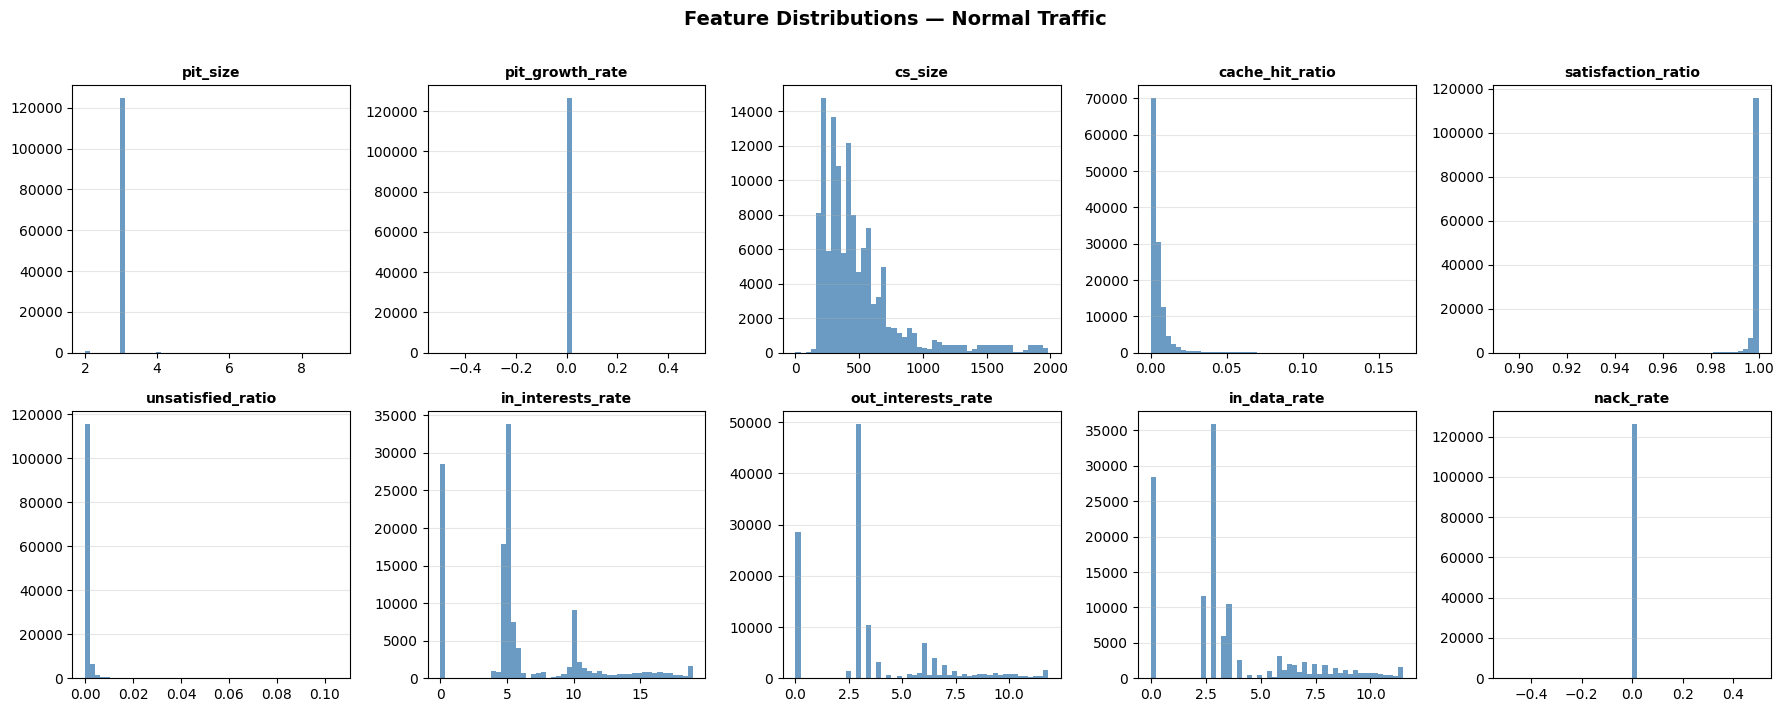

📁 Saved → results/feature_distributions.png


In [15]:
# ── Feature distributions
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(feat_df[col], bins=50, color='steelblue', alpha=0.8, edgecolor='none')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions — Normal Traffic', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/feature_distributions.png")

📡 Samples per node:


,n_samples
node,
bottleneck,5356
c1,11563
c2,11556
c3,11564
c4,5680
c5,5682
c6,5681
p1,11559
p2,11555


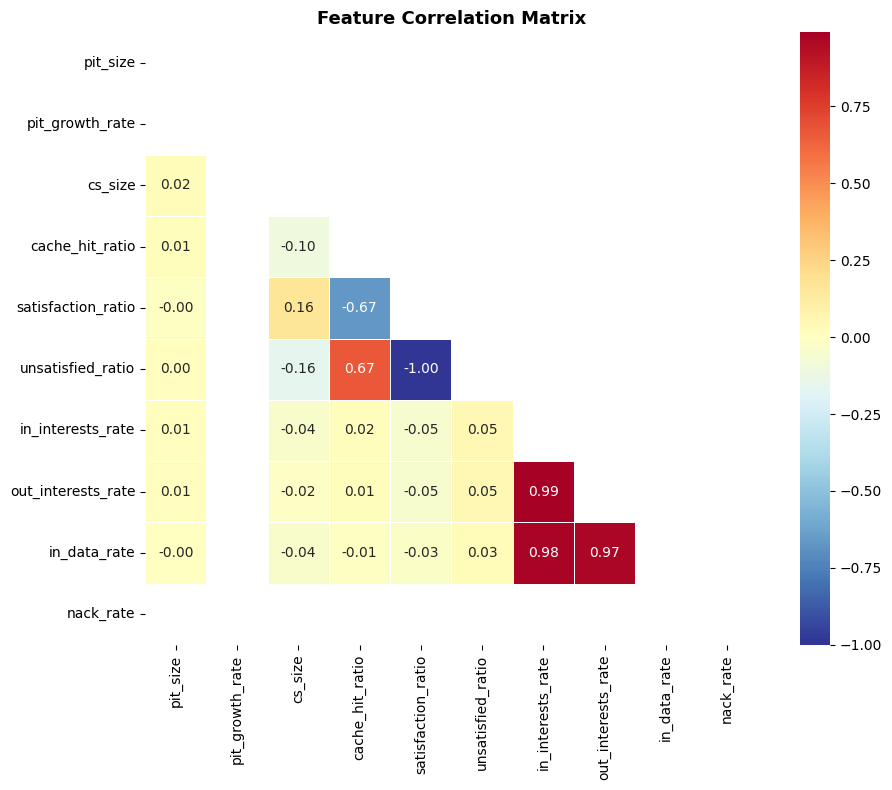

📁 Saved → results/feature_correlation.png


In [16]:
# ── Per-node sample counts
print("📡 Samples per node:")
display(feat_df.groupby('node').size().rename('n_samples').to_frame())

# ── Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = feat_df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/feature_correlation.png")

In [17]:
# Store the cleaned and feature-engineered dataset for later use
datasets_dir = Path(DATASETS_DIR)
datasets_dir.mkdir(parents=True, exist_ok=True)
out_file = datasets_dir / "normal_traffic_features.csv"
feat_df.to_csv(out_file, index=False)
print(f"📁 Cleaned dataset saved to: {out_file}")

📁 Cleaned dataset saved to: ../Datasets/normal_traffic_features.csv


### Creating anomaly and normal feature datasets
- Build normal features from `logs1`, `logs_mesh1`, `logs_dumbbell1`.
- Build anomaly features from `logs_dumbbell_ifa`, `logs_tree_cp`.
- Apply the same preprocessing and feature engineering to both.
- Add labels (`0=normal`, `1=anomaly`) and save one combined dataset.

In [18]:
# ---- Build mixed normal+anomaly dataset with the SAME preprocessing pipeline ----
NORMAL_SCENARIOS = ["logs1", "logs_mesh1", "logs_dumbbell1"]
ATTACK_SCENARIOS = ["logs_dumbbell_ifa", "logs_tree_cp"]
ATTACK_START_SECONDS = 600  # 10 minutes

def attack_relabel_rule(row: pd.Series, attack_start_seconds: int = ATTACK_START_SECONDS) -> int:
    """Node/scenario-specific relabeling for attack scenarios."""
    scenario = str(row.get("source_scenarios", ""))
    node = str(row.get("node", ""))
    elapsed = row.get("elapsed_sec", float("nan"))

    # logs_dumbbell_ifa: c1 flips to anomaly after attack start; all others normal.
    if scenario == "logs_dumbbell_ifa":
        if node == "c1":
            return int(pd.notna(elapsed) and elapsed >= attack_start_seconds)
        return 0

    # logs_tree_cp: malicious producer p2 is anomaly; all others normal.
    if scenario == "logs_tree_cp":
        return int(node == "p2")

    # Any other scenario defaults to normal.
    return 0

def prepare_feature_dataset(
    scenarios: list[str],
    class_label: int,
    class_name: str,
    warmup_seconds: int = WARMUP_SECONDS,
    clip_rates: bool = True,
    clip_quantiles: tuple[float, float] = (0.01, 0.99),
    relabel_fn=None,
    keep_elapsed: bool = False,
) -> pd.DataFrame:
    """
    Run the full preprocessing flow for a set of scenarios:
      1) extract logs
      2) parse timestamp + elapsed seconds
      3) warmup removal
      4) cleaning
      5) feature engineering
      6) optional per-class clipping
      7) add labels
    """
    # 1) Extract
    raw = extract_selected_logs(LOG_ROOT, scenarios).copy()

    # 2) Parse timestamp + elapsed time
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], errors="coerce")
    raw = raw.dropna(subset=["timestamp"]).copy()
    raw["elapsed_sec"] = raw.groupby("_source_node")["timestamp"].transform(
        lambda t: (t - t.min()).dt.total_seconds()
    )

    # 3) Remove startup warmup
    pre_df = raw[raw["elapsed_sec"] >= warmup_seconds].copy()

    # 4) Clean raw records
    cleaned = clean_logs(pre_df.copy())

    # 5) Feature engineering
    feats = engineer_features(cleaned)

    # 6) Optional: clip rate features again within this subset only
    if clip_rates:
        rate_cols = [
            "pit_growth_rate", "in_interests_rate",
            "out_interests_rate", "in_data_rate", "nack_rate"
        ]
        q_lo, q_hi = clip_quantiles
        for col in rate_cols:
            lo = feats[col].quantile(q_lo)
            hi = feats[col].quantile(q_hi)
            feats[col] = feats[col].clip(lo, hi)

    # Keep one scenario provenance column and drop redundant internal scenario key.
    if "_scenario" in feats.columns:
        feats["source_scenarios"] = feats["_scenario"].astype(str)
    else:
        feats["source_scenarios"] = class_name

    # 7) Labels
    if relabel_fn is None:
        feats["label"] = int(class_label)
        feats["class_name"] = class_name
    else:
        feats["label"] = feats.apply(relabel_fn, axis=1).astype(int)
        feats["class_name"] = feats["label"].map({0: "normal", 1: "anomaly"})

    # Optional cleanup of internal provenance columns
    drop_cols = ["_source_node", "_source_file", "_scenario"]
    if not keep_elapsed:
        drop_cols.append("elapsed_sec")
    feats = feats.drop(columns=drop_cols, errors="ignore")
    return feats

In [19]:
# ---- Generate normal and anomaly feature datasets ----
normal_df = prepare_feature_dataset(
    scenarios=NORMAL_SCENARIOS,
    class_label=0,
    class_name="normal",
    warmup_seconds=WARMUP_SECONDS,
    relabel_fn=None,
    keep_elapsed=False,

)

anomaly_df = prepare_feature_dataset(
    scenarios=ATTACK_SCENARIOS,
    class_label=0,
    class_name="normal",
    warmup_seconds=0,  # keep pre-attack traffic to allow time-based relabeling on c1
    relabel_fn=attack_relabel_rule,
    keep_elapsed=False,

)

print("\nAnomaly-source relabel check (scenario/node/label):")
display(
    anomaly_df.groupby(["source_scenarios", "node", "label"]).size()
    .rename("n_rows")
    .reset_index()
    .sort_values(["source_scenarios", "node", "label"])

)

# Mixed = simple combination of normal and anomaly traffic features
mixed_df = pd.concat([normal_df, anomaly_df], ignore_index=True)

# Shuffle rows for downstream model splitting reproducibly
mixed_df = mixed_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("\nMixed feature dataset created")
print(f"Normal rows  : {len(normal_df):,}")
print(f"Anomaly rows : {len(anomaly_df):,}")
print(f"Total rows   : {len(mixed_df):,}")

print("\nLabel distribution:")
display(mixed_df["label"].value_counts().sort_index().rename_axis("label").to_frame("n_rows"))

print("\nSamples by class and node (top 40):")
display(
    mixed_df.groupby(["class_name", "node"]).size()
    .rename("n_rows")
    .reset_index()
    .sort_values(["class_name", "node"])
    .head(40)

)

# Save outputs to Datasets folder for later use
datasets_dir = Path(DATASETS_DIR)
datasets_dir.mkdir(parents=True, exist_ok=True)

normal_out = datasets_dir / "normal_traffic_features.csv"
anomaly_out = datasets_dir / "anomaly_traffic_features.csv"
mixed_out = datasets_dir / "ndn_mixed_normal_anomaly_features.csv"

normal_df.to_csv(normal_out, index=False)
anomaly_df.to_csv(anomaly_out, index=False)
mixed_df.to_csv(mixed_out, index=False)

print(f"\nSaved normal features : {normal_out}")
print(f"Saved anomaly features: {anomaly_out}")
print(f"Saved mixed features  : {mixed_out}")

mixed_df.head()

Found 34 files from scenarios: ['logs1', 'logs_mesh1', 'logs_dumbbell1']


Parsing logs: 100%|██████████| 34/34 [00:00<00:00, 68.80it/s] 



Raw records loaded: 130,610
Columns: ['timestamp', 'node', 'nPitEntries', 'nInInterests', 'nOutInterests', 'nInData', 'nInNacks', 'nOutNacks', 'nSatisfiedInterests', 'nUnsatisfiedInterests', 'nCsEntries', 'nHits', 'nMisses', '_source_node', '_scenario', '_source_file', 'error']
🗑️  Error records dropped   : 42
📥 Raw records              : 126,529
✅ Clean records retained   : 126,436
🔁 Duplicates removed       : 51
📡 Nodes present            : ['bottleneck', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']


Feature engineering: 100%|██████████| 13/13 [00:00<00:00, 462.22it/s]



📐 Feature rows (after diff drop + clip): 126,423  (dropped 13)
Found 22 files from scenarios: ['logs_dumbbell_ifa', 'logs_tree_cp']


...

,n_rows
label,
0,160072
1,3109



Samples by class and node (top 40):


,class_name,node,n_rows
0,anomaly,c1,1757
1,anomaly,p2,1352
2,normal,bottleneck,7410
3,normal,c1,13213
4,normal,c2,14963
5,normal,c3,14970
6,normal,c4,7031
7,normal,c5,7033
8,normal,c6,7032
9,normal,p1,14965



Saved normal features : ../Datasets/normal_traffic_features.csv
Saved anomaly features: ../Datasets/anomaly_traffic_features.csv
Saved mixed features  : ../Datasets/ndn_mixed_normal_anomaly_features.csv


,timestamp,node,pit_size,pit_growth_rate,cs_size,cache_hit_ratio,satisfaction_ratio,unsatisfied_ratio,in_interests_rate,out_interests_rate,in_data_rate,nack_rate,source_scenarios,label,class_name
0,2026-03-12 16:52:47.201073,c6,3.0,0.0,231.0,0.007918,0.998873,0.001127,4.920955,3.444668,2.952573,0.0,logs1,0,normal
1,2026-03-13 07:15:54.762309,c1,3.0,0.0,434.0,0.001353,0.999874,0.000126,0.000000,0.000000,0.000000,0.0,logs_dumbbell1,0,normal
2,2026-03-13 03:38:42.435896,r4,3.0,0.0,521.0,0.007776,0.997340,0.002660,4.959424,2.975655,2.479712,0.0,logs_mesh1,0,normal
3,2026-03-13 03:23:20.528600,r4,3.0,0.0,371.0,0.022656,0.992606,0.007394,4.945655,2.967393,2.472827,0.0,logs_mesh1,0,normal
4,2026-03-13 04:41:23.872811,c2,3.0,0.0,469.0,0.002725,0.999745,0.000255,4.929822,2.957893,2.464911,0.0,logs_mesh1,0,normal


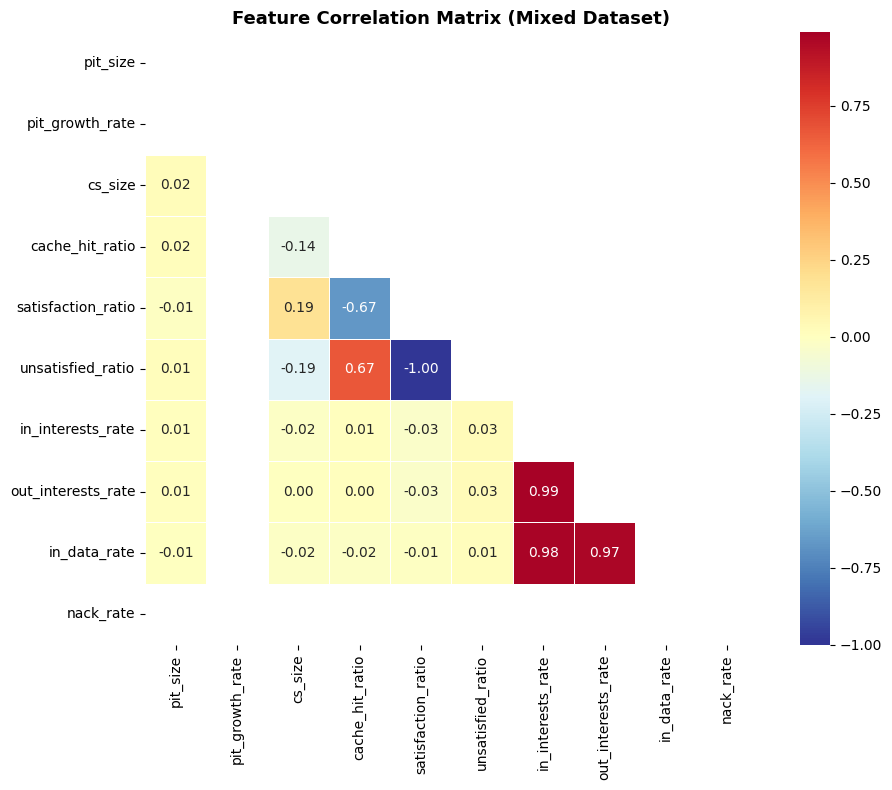

📁 Saved → results/mixed_feature_correlation.png


In [20]:
#Creating correlation heatmap for the mixed dataset
fig, ax = plt.subplots(figsize=(10, 8))
corr = mixed_df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix (Mixed Dataset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/mixed_feature_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/mixed_feature_correlation.png")

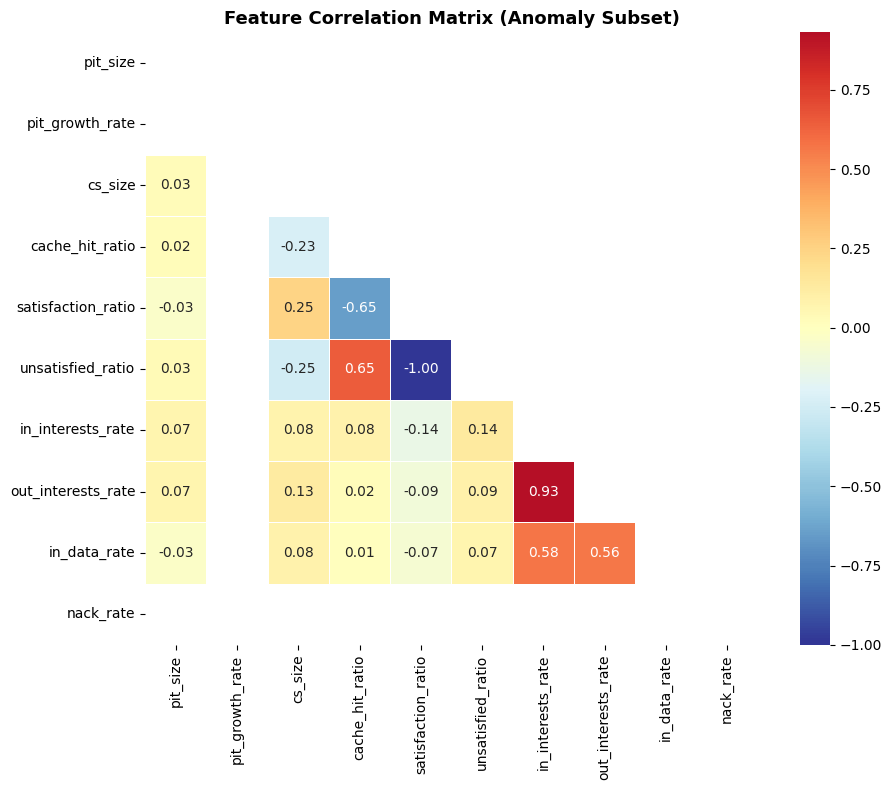

📁 Saved → results/anomaly_feature_correlation.png


In [21]:
#Correlation heatmap for the anomaly subset only
fig, ax = plt.subplots(figsize=(10, 8))
corr = anomaly_df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix (Anomaly Subset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/anomaly_feature_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/anomaly_feature_correlation.png")

### Export attack-specific test datasets
Create separate anomaly-source test datasets so model testing can be run per attack family.
- `ifa_attack_features.csv` from `logs_dumbbell_ifa`
- `cp_attack_features.csv` from `logs_tree_cp`

In [22]:
# ---- Export separate attack-specific datasets (IFA and CP) ----
datasets_dir = Path(DATASETS_DIR)
datasets_dir.mkdir(parents=True, exist_ok=True)

# Prefer in-memory anomaly_df if available; fallback to saved CSV.
if "anomaly_df" in globals():
    anom_src = anomaly_df.copy()
else:
    anom_src = pd.read_csv(datasets_dir / "anomaly_traffic_features.csv")

if "source_scenarios" not in anom_src.columns:
    raise ValueError("Expected column 'source_scenarios' not found in anomaly dataset.")

ifa_test_df = anom_src[anom_src["source_scenarios"].astype(str) == "logs_dumbbell_ifa"].copy()
cp_test_df = anom_src[anom_src["source_scenarios"].astype(str) == "logs_tree_cp"].copy()

ifa_out = datasets_dir / "ifa_attack_features.csv"
cp_out = datasets_dir / "cp_attack_features.csv"

ifa_test_df.to_csv(ifa_out, index=False)
cp_test_df.to_csv(cp_out, index=False)

print("✅ Attack-specific datasets saved")
print(f"IFA rows: {len(ifa_test_df):,} -> {ifa_out}")
print(f"CP  rows: {len(cp_test_df):,} -> {cp_out}")

print("\nIFA label distribution:")
display(ifa_test_df["label"].value_counts().sort_index().rename_axis("label").to_frame("n_rows"))

print("\nCP label distribution:")
display(cp_test_df["label"].value_counts().sort_index().rename_axis("label").to_frame("n_rows"))

✅ Attack-specific datasets saved
IFA rows: 20,533 -> ../Datasets/ifa_attack_features.csv
CP  rows: 16,225 -> ../Datasets/cp_attack_features.csv

IFA label distribution:


,n_rows
label,
0,18776
1,1757



CP label distribution:


,n_rows
label,
0,14873
1,1352
